# 02 - SVM Query Intent Classifier

**Bio-Heritage AI: RAG-Based Sri Lankan Herb Knowledge Assistant**

Step 4 of the methodology. We train a TF-IDF + Linear SVM classifier to label each user query as one of 4 intents:
- `herb-disease`  (e.g. "which herbs are used for diabetes")
- `herb-property` (e.g. "what is Gotukola used for")
- `dosage`        (e.g. "what is the dosage of Iramusu")
- `contraindication` (e.g. "is Kohomba safe during pregnancy")

We build a labelled query dataset using templates + real herb names from the knowledge base (synthetic data is allowed for this component), save it to `data/labelled_intent_queries.csv`, train the model, evaluate it, and save `models/intent_classifier.pkl`.

In [1]:
import json, os, random, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

random.seed(42)
np.random.seed(42)

CHUNKS_PATH = "../chunks/herb_chunks.json"
if not os.path.exists(CHUNKS_PATH):
    CHUNKS_PATH = "chunks/herb_chunks.json"
DATA_DIR = os.path.normpath(os.path.join(os.path.dirname(CHUNKS_PATH), "..", "data"))
MODEL_DIR = os.path.normpath(os.path.join(os.path.dirname(CHUNKS_PATH), "..", "models"))
os.makedirs(MODEL_DIR, exist_ok=True)
QUERIES_CSV = os.path.join(DATA_DIR, "labelled_intent_queries.csv")
MODEL_PATH = os.path.join(MODEL_DIR, "intent_classifier.pkl")

In [2]:
# Get real herb names to make queries realistic
with open(CHUNKS_PATH, "r", encoding="utf-8") as f:
    chunks = json.load(f)

herb_names = []
for c in chunks:
    for key in ("herb_name_sinhala", "herb_name_english"):
        v = str(c.get(key, "")).strip()
        if v:
            herb_names.append(v)
herb_names = list(dict.fromkeys(herb_names))  # unique, keep order
print("Unique herb names available:", len(herb_names))

diseases = [
    "diabetes", "fever", "skin diseases", "wounds", "cough", "cold",
    "high blood pressure", "digestive disorders", "arthritis", "anxiety",
    "headache", "memory problems", "urinary disorders", "diarrhoea", "asthma"
]

Unique herb names available: 1928


In [3]:
# Query templates per intent
templates = {
    "herb-disease": [
        "which herbs are used for {d}", "what herb helps with {d}", "best herb for {d}",
        "herbs for {d}", "any herbal treatment for {d}", "what can i take for {d}",
        "natural remedy for {d}", "which plant is good for {d}"
    ],
    "herb-property": [
        "what is {h} used for", "what are the properties of {h}", "what is {h}",
        "tell me about {h}", "what are the medical properties of {h}",
        "what are the benefits of {h}", "describe {h}", "uses of {h}"
    ],
    "dosage": [
        "what is the dosage of {h}", "how much {h} should i take", "recommended dose of {h}",
        "how many grams of {h}", "daily dosage for {h}", "correct dose of {h}",
        "how do i take {h}", "what quantity of {h} is safe"
    ],
    "contraindication": [
        "is {h} safe during pregnancy", "can i take {h} with diabetes medicine",
        "side effects of {h}", "is {h} safe for kidney disease", "contraindications of {h}",
        "can i use {h} while breastfeeding", "is {h} safe with my medication",
        "does {h} have any risks"
    ],
}

rows = []
N_PER_TEMPLATE = 40  # samples per template
for intent, temps in templates.items():
    for t in temps:
        for _ in range(N_PER_TEMPLATE):
            if "{h}" in t:
                q = t.format(h=random.choice(herb_names))
            else:
                q = t.format(d=random.choice(diseases))
            rows.append({"query": q, "intent": intent})

df = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
df.to_csv(QUERIES_CSV, index=False, encoding="utf-8")
print("Total labelled queries:", len(df))
print(df["intent"].value_counts())
df.head()

Total labelled queries: 1066
intent
contraindication    317
dosage              316
herb-property       315
herb-disease        118
Name: count, dtype: int64


,query,intent
0,best herb for wounds,herb-disease
1,can i take Bonatana with diabetes medicine,contraindication
2,uses of Rudaaru,herb-property
3,is Babutana safe with my medication,contraindication
4,can i take Kolubatu with diabetes medicine,contraindication


In [4]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    df["query"], df["intent"], test_size=0.2, random_state=42, stratify=df["intent"]
)

# TF-IDF + Linear SVM pipeline
clf = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("svm", LinearSVC()),
])
clf.fit(X_train, y_train)
print("Training complete.")

Training complete.


Accuracy: 1.0

Classification report:

                  precision    recall  f1-score   support

contraindication       1.00      1.00      1.00        64
          dosage       1.00      1.00      1.00        63
    herb-disease       1.00      1.00      1.00        24
   herb-property       1.00      1.00      1.00        63

        accuracy                           1.00       214
       macro avg       1.00      1.00      1.00       214
    weighted avg       1.00      1.00      1.00       214



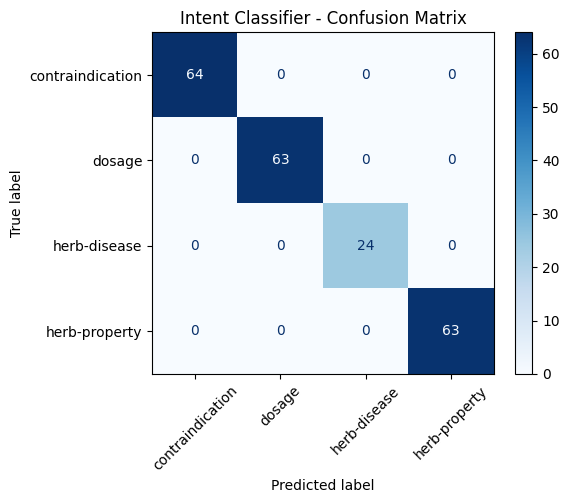

In [5]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

labels = sorted(df["intent"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Intent Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

In [6]:
# Save the trained pipeline
with open(MODEL_PATH, "wb") as f:
    pickle.dump(clf, f)
print("Saved model ->", MODEL_PATH)

# Quick manual test
tests = [
    "what is Gotukola used for",
    "which herbs are good for diabetes",
    "what is the dosage of Iramusu",
    "is Kohomba safe during pregnancy",
]
for q in tests:
    print(f"  '{q}' -> {clf.predict([q])[0]}")

print("\nDay 2 done. Next: Day 3 - health-context module + contraindication classifier.")

Saved model -> ..\models\intent_classifier.pkl
  'what is Gotukola used for' -> herb-property
  'which herbs are good for diabetes' -> herb-disease
  'what is the dosage of Iramusu' -> dosage
  'is Kohomba safe during pregnancy' -> contraindication

Day 2 done. Next: Day 3 - health-context module + contraindication classifier.
